In [2]:
import numpy as np
from scipy import stats
import pandas as pd

from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

# Data Loading

[Ref] https://archive.ics.uci.edu/dataset/242/energy+efficiency

In [4]:
path = "ENB2012_data.xlsx"
df = pd.read_excel(path)
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Overall_Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Area_Distribution",
    "Heating_Load",
    "Cooling_Load",
]
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


# Preprocessing

In [7]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [14]:
df["Surface_Area"].value_counts()

Surface_Area
514.5    64
563.5    64
588.0    64
612.5    64
637.0    64
661.5    64
686.0    64
710.5    64
735.0    64
759.5    64
784.0    64
808.5    64
Name: count, dtype: int64

In [8]:
df["Orientation"].value_counts()

Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64

In [9]:
df["Glazing_Area_Distribution"].value_counts()

Glazing_Area_Distribution
1    144
2    144
3    144
4    144
5    144
0     48
Name: count, dtype: int64

# EDA

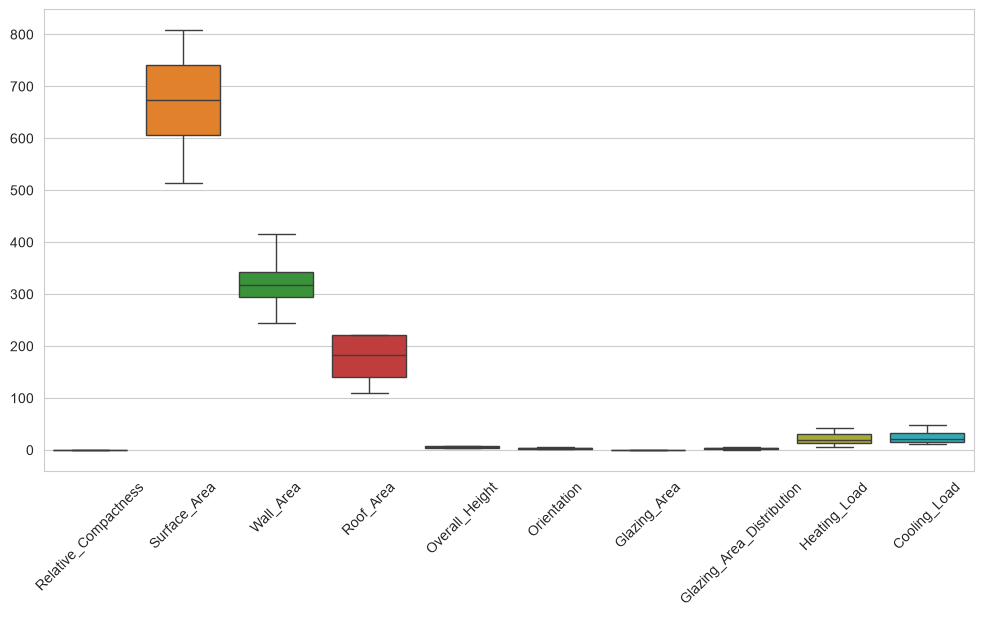

In [10]:
plt.figure(figsize=(12, 6))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.show()

In [11]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,2.041777,-1.785875,-0.561951,-1.470077,1.0,-1.341641,-1.760447,-1.814575,-0.670115,-0.342666
1,2.041777,-1.785875,-0.561951,-1.470077,1.0,-0.447214,-1.760447,-1.814575,-0.670115,-0.342666
2,2.041777,-1.785875,-0.561951,-1.470077,1.0,0.447214,-1.760447,-1.814575,-0.670115,-0.342666
3,2.041777,-1.785875,-0.561951,-1.470077,1.0,1.341641,-1.760447,-1.814575,-0.670115,-0.342666
4,1.284979,-1.229239,0.000000,-1.198678,1.0,-1.341641,-1.760447,-1.814575,-0.145503,0.388366


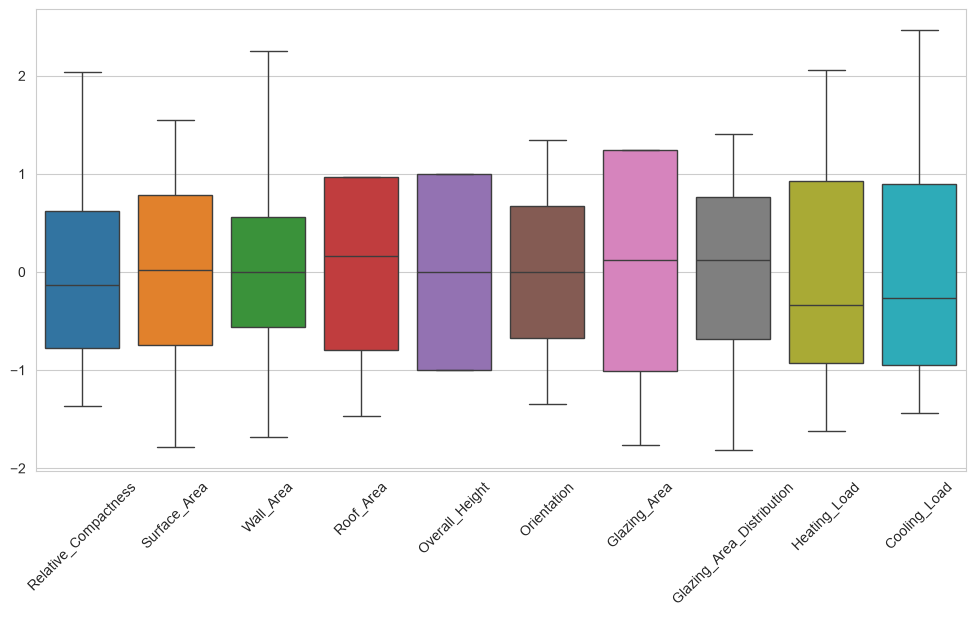

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(df_scaled)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Relative_Compactness', ylabel='Cooling_Load'>

<Figure size 1200x1000 with 0 Axes>

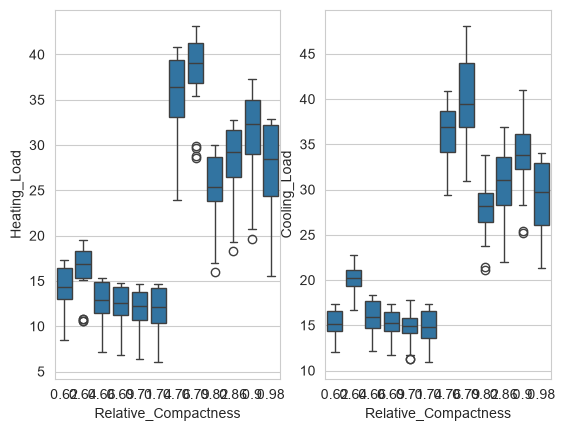

In [13]:
plt.figure(figsize=(12, 10))
fig, ax=plt.subplots(nrows=1, ncols=2)
sns.boxplot(data=df, x="Relative_Compactness", y= "Heating_Load", ax=ax[0])
sns.boxplot(data=df, x="Relative_Compactness", y="Cooling_Load", ax=ax[1])

<Axes: xlabel='Surface_Area', ylabel='Cooling_Load'>

<Figure size 1200x1000 with 0 Axes>

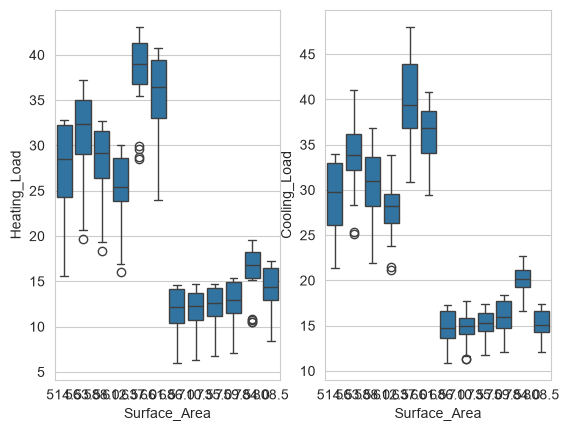

In [15]:
plt.figure(figsize=(12, 10))
fig, ax=plt.subplots(nrows=1, ncols=2)
sns.boxplot(data=df, x="Surface_Area", y= "Heating_Load", ax=ax[0])
sns.boxplot(data=df, x="Surface_Area", y="Cooling_Load", ax=ax[1])

<Axes: xlabel='Overall_Height', ylabel='Cooling_Load'>

<Figure size 1200x1000 with 0 Axes>

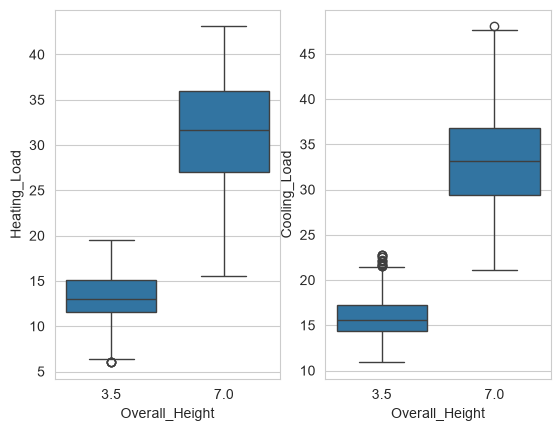

In [ ]:
plt.figure(figsize=(12, 10))
fig, ax=plt.subplots(nrows=1, ncols=2)
sns.boxplot(data=df, x="Overall_Height", y= "Heating_Load", ax=ax[0])
sns.boxplot(data=df, x="Overall_Height", y="Cooling_Load", ax=ax[1]) 

<Axes: >

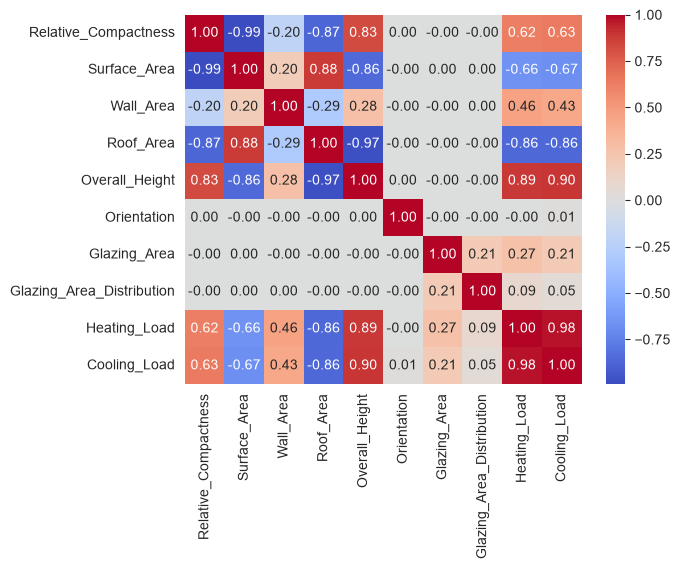

In [17]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")